### Notebook 02 — Baseline Classification Experiments with SageMaker MLflow App

Module: ITI113 Machine Learning & Operations
Focus Area: B — Model Development + C — MLOps (Experiment Tracking)
Project: Airbnb Instant Booking Prediction — binary classification on instant_bookable
Estimated Runtime: 10–20 minutes

# What this notebook does

1. This is the AWS-native experiments notebook. It connects to the SageMaker MLflow App / Serverless MLflow provisioned in 01A_setup_sagemaker_mlflow_app_(with_team_tags).ipynb and consumes the preprocessed feature matrices generated by 01_eda_and_feature_engineering.ipynb.

2. Connects to the team's SageMaker MLflow App and validates the TeamId tag before logging any runs.

3. Defines a classification metric suite (ROC-AUC, PR-AUC / Average Precision, F1-score, Precision, Recall, Log Loss, and Balanced Accuracy) tailored to evaluate potential class imbalance.

4. Run 1 — Logistic Regression (L2 / ElasticNet): the interpretable linear baseline.

5. Run 2 — Random Forest Classifier and Run 3 — Hist Gradient Boosting Classifier: the ensemble-tree benchmark models.

6. Run 4 — Hyperparameter Tuning: optimization with nested parent/child MLflow runs.

7. Programmatic run comparison, threshold selection, a production quality gate, and best_model.json export for Notebook 03.

8. A classification error-analysis deep dive on the winning model: 
    Probability calibration & reliability diagrams
    Confusion matrix and classification threshold tuning
    ROC & Precision-Recall curves 
    Per-city / per-property-type performance decomposition 
    Feature importance & SHAP values
    Forensic inspection of high-confidence false positives and false negatives


## Expected setup from Notebook 01A

Notebook 01A created the team MLflow App and saved a local config file that this notebook auto-discovers:

```text
mlflow_app_config_<team_id>.json
mlflow_app_config_<team_id>_<student_id>.json
```

Example App ARN shape: `arn:aws:sagemaker:ap-southeast-1:<account-id>:mlflow-app/app-XXXXXXXXX`

The training data comes from the same team S3 prefix used in Notebook 01. Before logging, this notebook **validates that the selected MLflow App carries `TeamId = TEAM_ID`** — with team-level IAM restriction, using another team's App should fail with 403, and this explicit check catches the mistake even earlier.

> **Prerequisite:** Notebook 01 must have produced `train_features.csv`, `train_labels.csv`, `test_features.csv`, `test_labels.csv` and `preprocessing_artifacts.json` (88-column feature contract, labels carrying `log_price` + raw `price`).

## Install or update required packages *(SageMaker Studio only)*

The `sagemaker-mlflow` plugin lets the standard MLflow client authenticate to the SageMaker MLflow App with IAM/SigV4 — no Databricks host or token. Uncomment on Studio and **restart the kernel** after installing. (This sandbox/local run uses a local SQLite MLflow store instead, so nothing needs installing here.)

In [1]:
# After running this cell, restart the kernel before continuing if packages were upgraded.
%pip install --upgrade "sagemaker>=2,<3" boto3 botocore

# SageMaker MLflow App support.
%pip install --upgrade mlflow sagemaker-mlflow

  Using cached sagemaker-2.257.6-py3-none-any.whl.metadata (19 kB)


Using cached sagemaker-2.257.6-py3-none-any.whl (1.7 MB)


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## 0. Configuration

Identical team/course constants as Notebooks 01/01A, plus **MLflow App discovery**: the notebook looks for the config JSON that 01A saved (team-level file first, then student-specific, then any team-matching file) and falls back to a hard-coded ARN only if no file is found. Off SageMaker, it degrades to a local SQLite tracking store (`sqlite:///mlflow_local.db`) so the whole experiment suite — including nested runs and `search_runs` comparison — still works end-to-end.

In [2]:
import os
import json
from pathlib import Path

import boto3
import sagemaker

session = sagemaker.Session()
role = sagemaker.get_execution_role()

# ============================================================
# Student / team settings
# ============================================================
TEAM_ID = "team14"
STUDENT_ID = "s1401"   # Change to your own student id, e.g. s4001, s4002, s4003

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "airbnb-instant-booking"
REGION = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

# ============================================================
# MLflow App config
# ------------------------------------------------------------
# Preferred:
# 1. Team-level config copied/shared from Notebook 01A:
#       mlflow_app_config_team40.json
# 2. Student-specific config from Notebook 01A:
#       mlflow_app_config_team40_s4002.json
# 3. Any local config matching this team:
#       mlflow_app_config_team40_*.json
#
# Important:
# Do not use another team's MLflow ARN. With team-level IAM
# restriction, wrong-team access should fail with 403.
# ============================================================

TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/airbnb-instant-booking"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_app_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = mlflow_app_config.get("MLFLOW_APP_ARN")
        MLFLOW_EXPERIMENT = mlflow_app_config.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# Fallback for classroom testing only.
# Update this to your team's MLflow App ARN from Notebook 01A if the config file
# is not available in this Studio workspace.
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:"
    "mlflow-app/app-PIGMOQJH46PS"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print(
        "[WARNING] No local MLflow config file found. "
        "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
    )
else:
    print(f"Loaded MLflow App config from {config_used}")

# Validate config team, if present
config_team_id = mlflow_app_config.get("TEAM_ID") or mlflow_app_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
        "Do not use another team's MLflow config."
    )

REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42

print("=" * 70)
print("ITI113 Baseline Experiments — SageMaker MLflow App")
print("=" * 70)
print(f"Team               : {TEAM_ID}")
print(f"Student            : {STUDENT_ID}")
print(f"S3 Prefix          : {PREFIX}")
print(f"MLflow App ARN     : {MLFLOW_APP_ARN}")
print(f"MLflow Experiment  : {MLFLOW_EXPERIMENT}")
print(f"Registered Model   : {REGISTERED_MODEL}")
print(f"SageMaker Role     : {role}")
print("=" * 70)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:8                                                                                    │
│                                                                                                  │
│     5 import boto3                                                                               │
│     6 import sagemaker                                                                           │
│     7                                                                                            │
│ ❱   8 session = sagemaker.Session()                                                              │
│     9 role = sagemaker.get_execution_role()                                                      │
│    10                                                                                            │
│    11 # ============================================================                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AttributeError: module 'sagemaker' has no attribute 'Session'

## 1. Connect to the MLflow App — with team-tag safety check

The classroom restricts each team's IAM role to MLflow Apps tagged with its own `TeamId` (`aws:ResourceTag/TeamId = team40`). Before a single byte is logged, this cell fetches the App's tags and refuses to continue if the tag doesn't match `TEAM_ID` — so a copy-pasted ARN from another team fails *loudly here* rather than silently polluting (or 403-ing halfway through) someone else's experiment history. Locally there are no AWS tags, so the check is reported as skipped and the file store is used.

In [ ]:
import mlflow
from mlflow.entities import LifecycleStage
from mlflow.tracking import MlflowClient

# 1. Connect to tracking server
mlflow.set_tracking_uri(MLFLOW_APP_ARN)

# 2. Check and restore if soft-deleted
client = MlflowClient()
existing_exp = client.get_experiment_by_name(MLFLOW_EXPERIMENT)

if existing_exp:
    if existing_exp.lifecycle_stage != LifecycleStage.ACTIVE:
        print(
            f"Experiment '{MLFLOW_EXPERIMENT}' was deleted. Restoring ID: {existing_exp.experiment_id}..."
        )
        client.restore_experiment(existing_exp.experiment_id)
        print("Restored successfully.")

# 3. Set as active experiment
mlflow.set_experiment(MLFLOW_EXPERIMENT)

In [ ]:
import mlflow
import boto3

sm_client = boto3.client("sagemaker", region_name=REGION)

# ============================================================
# Safety check for team-level MLflow restriction
# ------------------------------------------------------------
# The selected MLflow App must have ResourceTag/TeamId = TEAM_ID.
# If a student accidentally uses another team's ARN, this should either:
# - fail with AccessDenied / 403 due to IAM restriction, or
# - fail this explicit validation before logging.
# ============================================================

try:
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App."
        )

    print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,          # kept for compatibility with previous notebooks
    "student": STUDENT_ID,    # kept for compatibility with previous notebooks
    "dataset": PROJECT_NAME,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
}

print(f"\nTracking URI : {mlflow.get_tracking_uri()}")

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment   : {exp.name}")
print(f"Experiment ID: {exp.experiment_id}")

# Optional: generate a presigned UI URL if the current role has permission.
try:
    url_response = sm_client.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN
    )
    mlflow_ui_url = (
        url_response.get("AuthorizedUrl")
        or url_response.get("Url")
        or url_response.get("PresignedUrl")
    )
    print("\nOpen the SageMaker MLflow UI:")
    print(mlflow_ui_url)
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)

In [3]:
# ==============================================================================
# CONNECT TO SAGEMAKER MLFLOW APP & GENERATE PRESIGNED URL
# ==============================================================================

import os
import glob
import json
from pathlib import Path
import boto3
import botocore
import mlflow

# ------------------------------------------------------------------------------
# 1. Environment & Configuration Settings
# ------------------------------------------------------------------------------
LOCAL_MODE = False
REGION = "ap-southeast-1" if "REGION" not in globals() else REGION
TEAM_ID = "team14" if "TEAM_ID" not in globals() else TEAM_ID
STUDENT_ID = "s1401" if "STUDENT_ID" not in globals() else STUDENT_ID
COURSE = "ITI113" if "COURSE" not in globals() else COURSE

# Initialize Boto3 SageMaker Client
sm_client = boto3.client("sagemaker", region_name=REGION)

# Discover MLflow App ARN from config or fallback
DEFAULT_MLFLOW_APP_ARN = "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS"

config_candidates = (
    [Path(f"mlflow_app_config_{TEAM_ID}.json"), Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")]
    + [Path(p) for p in sorted(glob.glob(f"mlflow_app_config_{TEAM_ID}_*.json"))]
)

MLFLOW_APP_ARN = None
for cand in config_candidates:
    if cand.exists():
        cfg = json.loads(cand.read_text())
        MLFLOW_APP_ARN = cfg.get("arn")
        print(f"Loaded MLflow App ARN from: {cand.name}")
        break

if not MLFLOW_APP_ARN:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print("Using DEFAULT_MLFLOW_APP_ARN")

# ------------------------------------------------------------------------------
# 2. Configure MLflow Tracking Client
# ------------------------------------------------------------------------------
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/InstantBooking-Classification"
MLFLOW_TRACKING_URI = MLFLOW_APP_ARN

# Set Tracking URI to the SageMaker MLflow Serverless ARN
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

_exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
MLFLOW_EXPERIMENT_ID = _exp.experiment_id if _exp else None

# ------------------------------------------------------------------------------
# 3. Presigned URL Helper Functions
# ------------------------------------------------------------------------------
MLFLOW_URL_EXPIRES_IN = 300           # Link redemption validity window (seconds)
MLFLOW_SESSION_DURATION = 3600        # Authenticated browser session duration (seconds)

def create_mlflow_app_presigned_url(fragment: str = "") -> str:
    """Return a presigned SageMaker MLflow App URL, optionally deep-linked to a specific UI route."""
    kwargs = dict(
        Arn=MLFLOW_APP_ARN,
        ExpiresInSeconds=MLFLOW_URL_EXPIRES_IN,
        SessionExpirationDurationInSeconds=MLFLOW_SESSION_DURATION
    )
    try:
        resp = sm_client.create_presigned_mlflow_app_url(**kwargs)
    except botocore.exceptions.ParamValidationError:
        resp = sm_client.create_presigned_mlflow_app_url(Arn=MLFLOW_APP_ARN)

    base = resp.get("AuthorizedUrl") or resp.get("Url")
    if not base:
        raise RuntimeError(f"No AuthorizedUrl/Url found in SageMaker response: {resp}")

    base = base.split("#", 1)[0]
    return f"{base}#{fragment.lstrip('#')}" if fragment else base

def print_mlflow_presigned_links(experiment_id=None, run_id=None, label=""):
    """Print authenticated presigned URLs for the experiment and/or run."""
    if label:
        print(f"--- {label} ---")
    if experiment_id is None:
        print("MLflow UI Base:")
        print("  " + create_mlflow_app_presigned_url())
        return

    print("Experiment UI:")
    print("  " + create_mlflow_app_presigned_url(f"/experiments/{experiment_id}"))
    if run_id:
        print("Run UI:")
        print("  " + create_mlflow_app_presigned_url(f"/experiments/{experiment_id}/runs/{run_id}"))
        
    print(
        f"\n(Link is redeemable for {MLFLOW_URL_EXPIRES_IN}s; "
        f"UI session lasts {MLFLOW_SESSION_DURATION}s — regenerate when expired)"
    )

# ------------------------------------------------------------------------------
# 4. Generate & Display Active Presigned Links
# ------------------------------------------------------------------------------
print("=" * 80)
print(f"CONNECTED TO SAGEMAKER MLFLOW APP")
print("=" * 80)
print(f"Tracking Server ARN : {MLFLOW_APP_ARN}")
print(f"Experiment Name     : {MLFLOW_EXPERIMENT} (ID: {MLFLOW_EXPERIMENT_ID})\n")

print_mlflow_presigned_links(
    experiment_id=MLFLOW_EXPERIMENT_ID,
    label="Airbnb Instant Booking Classification"
)

Using DEFAULT_MLFLOW_APP_ARN


CONNECTED TO SAGEMAKER MLFLOW APP
Tracking Server ARN : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Experiment Name     : ITI113/team14/InstantBooking-Classification (ID: 2)

--- Airbnb Instant Booking Classification ---
Experiment UI:


  https://app-PIGMOQJH46PS.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IjVJNjZSWSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNGVFaHRlbVBrR0dHbnZSUXpIVlE2RTRNNm9WMnc1c1gxU1RqaVhyTWFqOVFBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGdE5HUTBTbEJJT1UxTFdXeHhaaTlqWW0xVllrZGpiV3hIWnpGTWEzaEpUak4xYTIweE1FUkhlV3BaVWpZeFkwTjJOVmRMVTBSSmJXNU9ZbE54UWxCSVVUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFUVDUzNWVmQzU0VkNMMXZjaUtpSENvQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF5dW9GL3FPWFYxcWlydUNnb0NBUkNBTzNBT1ZsNk1FdXRuTTRsQm9xOU9DN1pvekREZS9wNS9hbUFQeitUWHliK3VsMjdxZUtoSS8xZUtyUWthSVRUQkQweHJxTk02ZTlubWRPWW9BZ0FBRUFEeWJYMkJyRGRDdC9zNkhROCtaY1JRbk9wN3N0cldvNWpTM1h2ZDZLaWlFU29PalpQVkpGYnZKZm9kWkE4Q0ZBdi8vLy8vQUFBQUFRQ

## 2. Load Processed Data (the Notebook 01 contract)

The matrices arrive model-ready: features are fully encoded and partitioned (standardised continuous predictors including within-city price and capacity ratios, host responsiveness indicators, missingness _isna flags, 30 top-K automation/amenity flags, and one-hot categorical levels), with zero missing values, no PII, and no target-derived leakage columns — all asserted again upon ingestion because trusting an upstream contract is not the same as re-validating it.The label vector contains instant_bookable (the discrete binary classification target: 1 for instant booking enabled, 0 for manual host approval required). 01_preprocessing_artifacts.json rides along so this notebook can access train-fitted imputation parameters, the top-30 amenity vocabulary, and scaling baselines when inspecting feature importances, calibration curves, and false-positive/false-negative edge cases in downstream evaluation.

Key Adaptations Made:Target 

- Definition: Binary classification target instant_bookable (0, 1).
- Feature Composition: Highlighted the specific engineered feature groups (within-city standardised price, host operational signals, missingness indicator flags, and check-in automation perks like smart locks/keypads).
- Artifact Context: Shifted the role of 01_preprocessing_artifacts.json from un-scaling regression price errors to providing train-fitted parameters for probability calibration, feature importance interpretation, and classification error analysis (false positives / false negatives).

In [6]:
import pandas as pd, numpy as np, io

s3 = boto3.client('s3')

def load_s3_csv(bucket, key):
    r = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(r['Body'].read()))

p = f'{PREFIX}/processed'
X_train = load_s3_csv(BUCKET, f'{p}/train_features.csv')
y_train = load_s3_csv(BUCKET, f'{p}/train_labels.csv').squeeze()
X_test  = load_s3_csv(BUCKET, f'{p}/test_features.csv')
y_test  = load_s3_csv(BUCKET, f'{p}/test_labels.csv').squeeze()

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test : {X_test.shape[0]}  rows')

Train: 222513 rows, 100 features
Test : 55629  rows


## 3. Helper Functions
Reusable logging helpers so every run captures identical metrics and artifacts. Consistent logging is what makes the MLflow comparison view useful.

In [7]:
import tempfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)

# ------------------------------------------------------------------------------
# 1. Comprehensive Model Evaluation Function
# ------------------------------------------------------------------------------
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    """
    Computes key classification and probability calibration metrics
    across train and test splits for instant-booking propensity.
    """
    metrics = {}
    for split, X, y in [('train', X_tr, y_tr), ('test', X_te, y_te)]:
        yp = model.predict(X)
        yb = model.predict_proba(X)[:, 1]
        
        metrics.update({
            f'{split}_accuracy'    : round(accuracy_score(y, yp), 4),
            f'{split}_precision'   : round(precision_score(y, yp, zero_division=0), 4),
            f'{split}_recall'      : round(recall_score(y, yp, zero_division=0), 4),
            f'{split}_f1'          : round(f1_score(y, yp, zero_division=0), 4),
            f'{split}_roc_auc'     : round(roc_auc_score(y, yb), 4),
            f'{split}_pr_auc'      : round(average_precision_score(y, yb), 4),
            f'{split}_log_loss'    : round(log_loss(y, yb), 4),
            f'{split}_brier_score' : round(brier_score_loss(y, yb), 4),
        })
    return metrics


# ------------------------------------------------------------------------------
# 2. Confusion Matrix Plotter
# ------------------------------------------------------------------------------
def log_confusion_matrix(model, X_te, y_te, title):
    """
    Plots and logs the confusion matrix with Instant Booking domain labels.
    """
    fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
    ConfusionMatrixDisplay.from_estimator(
        model, 
        X_te, 
        y_te,
        display_labels=['Manual (0)', 'Instant (1)'],
        cmap='Blues', 
        ax=ax,
        values_format='d'
    )
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    plt.tight_layout()
    
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/confusion_matrix.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path='plots')
    plt.show()
    plt.close(fig)


# ------------------------------------------------------------------------------
# 3. ROC Curve Plotter
# ------------------------------------------------------------------------------
def log_roc_curve(model, X_te, y_te, title):
    """
    Plots and logs the ROC curve with reference baseline.
    """
    fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=ax, name=title)
    ax.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')
    ax.set_title(f'ROC Curve — {title}', fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/roc_curve.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path='plots')
    plt.show()
    plt.close(fig)


# ------------------------------------------------------------------------------
# 4. Precision-Recall Curve Plotter
# ------------------------------------------------------------------------------
def log_pr_curve(model, X_te, y_te, title):
    """
    Plots and logs the Precision-Recall curve (essential for imbalanced targets).
    """
    fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
    PrecisionRecallDisplay.from_estimator(model, X_te, y_te, ax=ax, name=title)
    
    # Baseline positive rate reference line
    baseline_rate = np.mean(y_te)
    ax.axhline(baseline_rate, color='red', linestyle='--', label=f'Baseline ({baseline_rate:.2f})')
    ax.set_title(f'PR Curve — {title}', fontweight='bold')
    ax.legend(loc='lower left')
    plt.tight_layout()
    
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/pr_curve.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path='plots')
    plt.show()
    plt.close(fig)


# ------------------------------------------------------------------------------
# 5. Feature Importance / Coefficient Plotter
# ------------------------------------------------------------------------------
def log_feature_importance(model, feature_names, title, top_n=20):
    """
    Plots and logs top-K feature importances (Tree models) or feature coefficients (Linear models).
    """
    # 1. Tree-based models (RandomForest, LightGBM, XGBoost)
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
        label = 'Feature Importance'
    # 2. Linear models (LogisticRegression)
    elif hasattr(model, 'coef_'):
        imp = pd.Series(model.coef_[0], index=feature_names)
        label = 'Log-Odds Coefficient'
    else:
        return

    # Select Top-N features by absolute magnitude
    top_imp = imp.reindex(imp.abs().sort_values(ascending=False).index[:top_n]).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
    top_imp.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='black')
    ax.set_title(f'Top {top_n} Features — {title}', fontweight='bold')
    ax.set_xlabel(label)
    plt.tight_layout()

    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/feature_importance.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path='plots')
    plt.show()
    plt.close(fig)

print('Instant Booking evaluation & MLflow logging helpers ready.')

Instant Booking evaluation & MLflow logging helpers ready.


## LOGISTIC REGRESS BASELINE

Training team14_s1401_logistic_regression_baseline...


/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


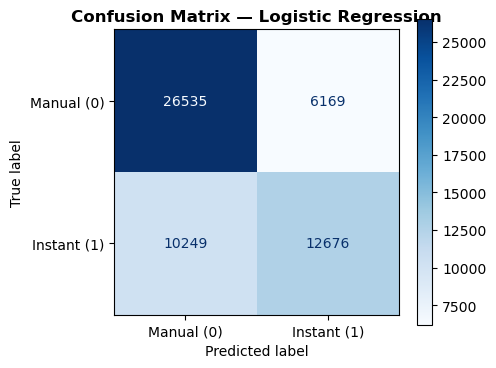

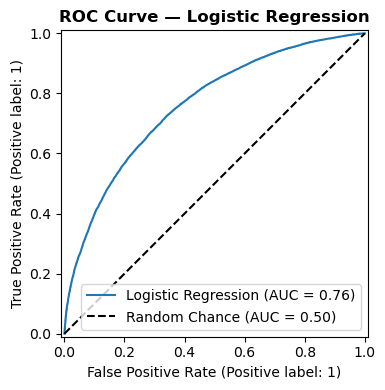

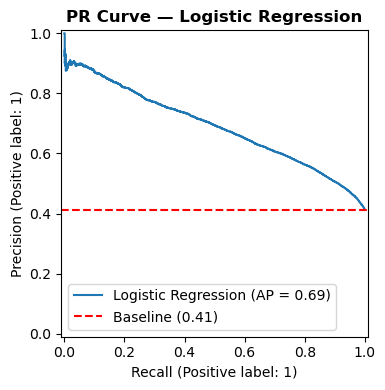

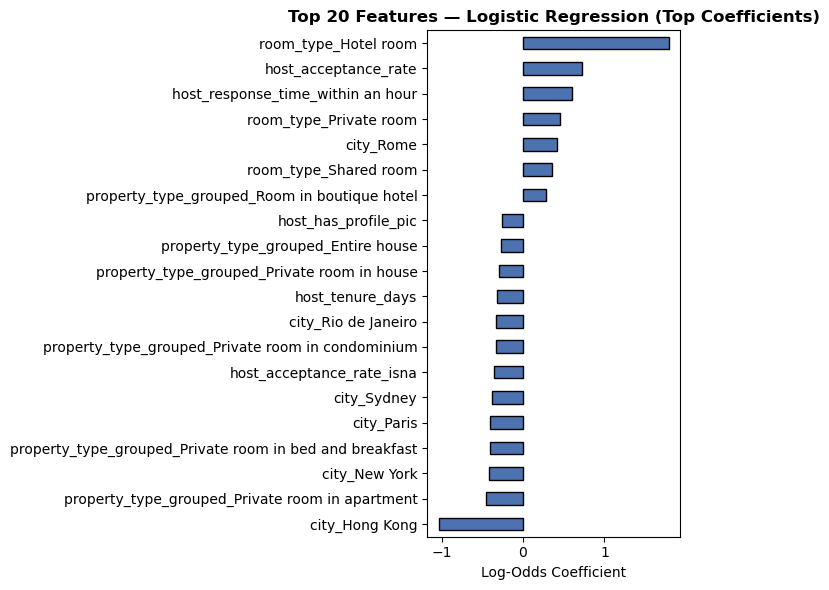

2026/08/26 03:58:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference tim

🏃 View run team14_s1401_logistic_regression_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/6f5160be6b3d4164bb3d93500cfad6c0
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2

LOGISTIC REGRESSION BASELINE RESULTS (Run ID: 6f5160be6b3d4164bb3d93500cfad6c0)
  TEST  test_accuracy            : 0.7049
  TEST  test_brier_score         : 0.1936
  TEST  test_f1                  : 0.6069
  TEST  test_log_loss            : 0.5708
  TEST  test_pr_auc              : 0.6895
  TEST  test_precision           : 0.6726
  TEST  test_recall              : 0.5529
  TEST  test_roc_auc             : 0.7612
  TRAIN train_accuracy           : 0.7026
  TRAIN train_brier_score        : 0.1943
  TRAIN train_f1                 : 0.6057
  TRAIN train_log_loss           : 0.5727
  TRAIN train_pr_auc             : 0.6879
  TRAIN train_precision          : 0.6677
  TRAIN train_recall             : 0.5543
  TRAIN train_roc_auc            : 0.7591


,Metric,Train,Test
0,Accuracy,0.7026,0.7049
1,ROC-AUC,0.7591,0.7612
2,PR-AUC,0.6879,0.6895
3,F1-Score,0.6057,0.6069
4,Precision,0.6677,0.6726
5,Recall,0.5543,0.5529
6,Log-Loss,0.5727,0.5708
7,Brier Score,0.1943,0.1936


In [8]:
# ==============================================================================
# RUN 1: LOGISTIC REGRESSION BASELINE
# ==============================================================================

import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.linear_model import LogisticRegression
from IPython.display import display
# 1. Configuration & Hyperparameters
run_name = f"{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline" if "TEAM_ID" in globals() else "01_Logistic_Regression_Baseline"

LR_PARAMS = {
    "C": 1.0,
    "penalty": "l2",
    "solver": "lbfgs",
    "max_iter": 1000,
    "random_state": 42,
}

# 2. Execute MLflow Run
with mlflow.start_run(run_name=run_name) as run:
    # --- Set Tags ---
    tags = {
        "model_family": "Linear",
        "model_type": "LogisticRegression",
        "experiment_stage": "Baseline",
        "target": "instant_bookable",
    }
    if "COMMON_TAGS" in globals():
        tags.update(COMMON_TAGS)
    mlflow.set_tags(tags)

    # --- Log Hyperparameters & Dataset Metadata ---
    mlflow.log_params({
        **LR_PARAMS,
        "n_features": X_train.shape[1],
        "train_size": X_train.shape[0],
    })

    # --- Train Model ---
    print(f"Training {run_name}...")
    model_lr = LogisticRegression(**LR_PARAMS)
    model_lr.fit(X_train, y_train)

    # --- Compute & Log Metrics ---
    metrics_lr = evaluate_model(model_lr, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics_lr)

    # --- Log Diagnostic Plots ---
    log_confusion_matrix(model_lr, X_test, y_test, title="Logistic Regression")
    log_roc_curve(model_lr, X_test, y_test, title="Logistic Regression")
    log_pr_curve(model_lr, X_test, y_test, title="Logistic Regression")
    log_feature_importance(
        model_lr,
        feature_names=X_train.columns,
        title="Logistic Regression (Top Coefficients)",
        top_n=20,
    )

    # --- Log Model Artifact ---
    mlflow.sklearn.log_model(
        sk_model=model_lr,
        artifact_path="model",
        input_example=X_train.head(5),
    )

    # --- Capture Run ID ---
    LR_RUN_ID = run.info.run_id

# ==============================================================================
# 3. Print Results & Display Performance Table
# ==============================================================================
print("\n" + "=" * 50)
print(f"LOGISTIC REGRESSION BASELINE RESULTS (Run ID: {LR_RUN_ID})")
print("=" * 50)

for k, v in sorted(metrics_lr.items()):
    split = "TRAIN" if k.startswith("train") else "TEST "
    print(f"  {split} {k:<25}: {v:.4f}" if isinstance(v, float) else f"  {split} {k:<25}: {v}")

# Display structured DataFrame in notebook environments
df_results_lr = pd.DataFrame([
    {"Metric": "Accuracy",     "Train": metrics_lr.get("train_accuracy"),     "Test": metrics_lr.get("test_accuracy")},
    {"Metric": "ROC-AUC",      "Train": metrics_lr.get("train_roc_auc"),      "Test": metrics_lr.get("test_roc_auc")},
    {"Metric": "PR-AUC",       "Train": metrics_lr.get("train_pr_auc"),       "Test": metrics_lr.get("test_pr_auc")},
    {"Metric": "F1-Score",     "Train": metrics_lr.get("train_f1"),           "Test": metrics_lr.get("test_f1")},
    {"Metric": "Precision",    "Train": metrics_lr.get("train_precision"),    "Test": metrics_lr.get("test_precision")},
    {"Metric": "Recall",       "Train": metrics_lr.get("train_recall"),       "Test": metrics_lr.get("test_recall")},
    {"Metric": "Log-Loss",     "Train": metrics_lr.get("train_log_loss"),     "Test": metrics_lr.get("test_log_loss")},
    {"Metric": "Brier Score",  "Train": metrics_lr.get("train_brier_score"),  "Test": metrics_lr.get("test_brier_score")},
])

display(df_results_lr)

## Run 2 — Random Forest Classifier Baseline

RANDOM FOREST BASELINE - START


>>> MLflow ready.



>>> RF PARAMETERS


    n_estimators: 50


    max_depth: 15


...

>>> MLflow Run ID: bae46f7f732d47379bcd471c93e4dcaa


>>> Tags logged.


>>> Parameters logged.


>>> Metrics logged.


>>> Logging confusion matrix...


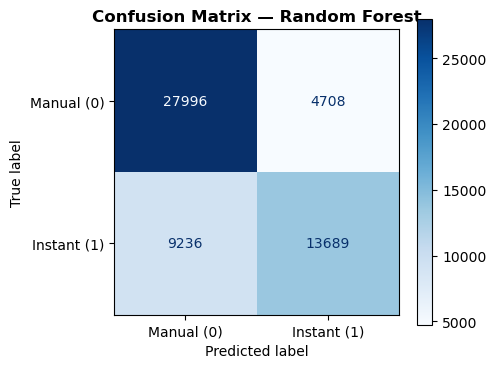

>>> Confusion matrix logged.


>>> Logging ROC curve...


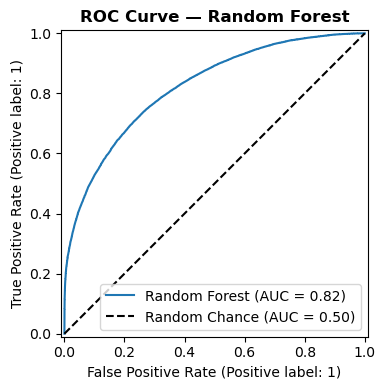

>>> ROC curve logged.


>>> Logging PR curve...


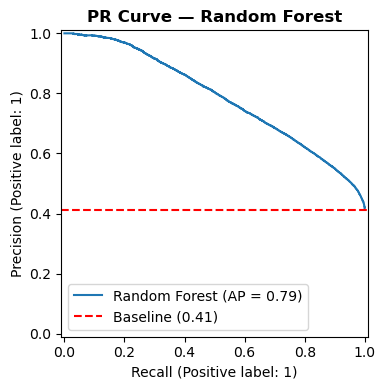

>>> PR curve logged.


>>> Logging feature importance...


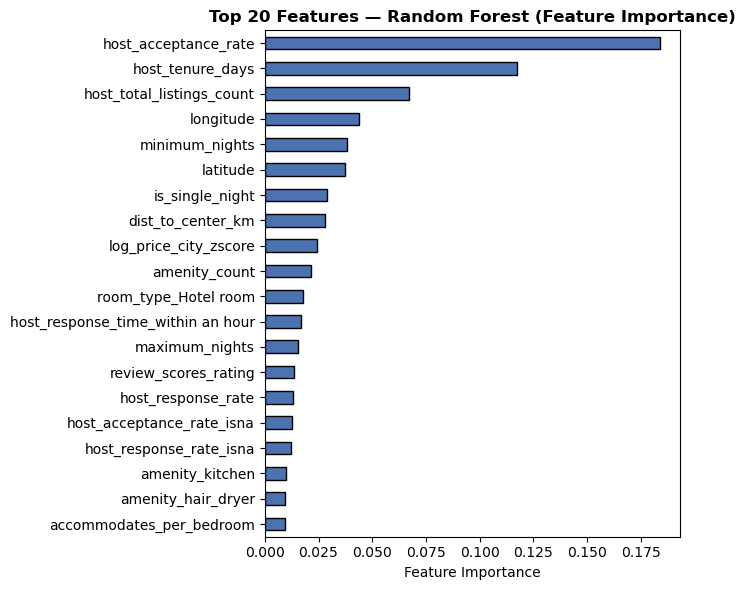

>>> Feature importance logged.


>>> Logging model artifact...


2026/08/26 03:59:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference tim

>>> Model artifact logged.


...

  TRAIN train_pr_auc             : 0.8565


  TRAIN train_precision          : 0.8178


  TRAIN train_recall             : 0.6621


  TRAIN train_roc_auc            : 0.8805


RANDOM FOREST BASELINE COMPLETED SUCCESSFULLY


In [9]:
# ==============================================================================
# RUN 2: RANDOM FOREST CLASSIFIER BASELINE
# ==============================================================================

import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display

print("=" * 70, flush=True)
print("RANDOM FOREST BASELINE - START", flush=True)
print("=" * 70, flush=True)

# ==============================================================================
# 1. CLOSE PREVIOUS MLflow RUN
# ==============================================================================

if mlflow.active_run() is not None:
    print(">>> Closing previous MLflow run...", flush=True)
    mlflow.end_run()
print(">>> MLflow ready.", flush=True)

# ==============================================================================
# 2. DEFINE RUN NAME AND PARAMETERS
# ==============================================================================

run_name = (
    f"{TEAM_ID}_{STUDENT_ID}_random_forest_baseline"
    if "TEAM_ID" in globals()
    else "02_Random_Forest_Baseline"
)

RF_PARAMS = {
    "n_estimators": 50,
    "max_depth": 15,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": 2,
}

print("\n>>> RF PARAMETERS", flush=True)

for k, v in RF_PARAMS.items():
    print(f"    {k}: {v}", flush=True)

# ==============================================================================
# 3. CREATE MODEL
# ==============================================================================

print("\n>>> Creating Random Forest...", flush=True)
model_rf = RandomForestClassifier(**RF_PARAMS)
print(">>> Model created.", flush=True)

# ==============================================================================
# 4. TRAIN MODEL
# ==============================================================================

print("\n>>> Starting training...", flush=True)
model_rf.fit(X_train, y_train)
print(">>> Training completed.", flush=True)

# ==============================================================================
# 5. EVALUATE MODEL
# ==============================================================================

print("\n>>> Starting evaluation...", flush=True)
metrics_rf = evaluate_model(
    model_rf,
    X_train,
    y_train,
    X_test,
    y_test
)

print(">>> Evaluation completed.", flush=True)
print("\n>>> RF RESULTS:", flush=True)
for k, v in sorted(metrics_rf.items()):
    print(f"    {k}: {v}", flush=True)

# ==============================================================================
# 6. START MLflow RUN
# ==============================================================================

print("\n>>> Starting MLflow logging...", flush=True)
with mlflow.start_run(run_name=run_name) as run:
    RF_RUN_ID = run.info.run_id
    print(
        f">>> MLflow Run ID: {RF_RUN_ID}",
        flush=True
    )
    
    # --------------------------------------------------------------------------
    # Tags
    # --------------------------------------------------------------------------

    tags = {
        "model_family": "Ensemble",
        "model_type": "RandomForestClassifier",
        "experiment_stage": "Baseline",
        "target": "instant_bookable",
    }

    if "COMMON_TAGS" in globals():
        tags.update(COMMON_TAGS)
    mlflow.set_tags(tags)
    print(">>> Tags logged.", flush=True)

    # --------------------------------------------------------------------------
    # Parameters
    # --------------------------------------------------------------------------

    mlflow.log_params({
        **RF_PARAMS,
        "n_features": X_train.shape[1],
        "train_size": X_train.shape[0],
    })
    print(">>> Parameters logged.", flush=True)
    
    # --------------------------------------------------------------------------
    # Metrics
    # --------------------------------------------------------------------------

    mlflow.log_metrics(metrics_rf)
    print(">>> Metrics logged.", flush=True)
    # --------------------------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------------------------

    print(">>> Logging confusion matrix...", flush=True)
    log_confusion_matrix(
        model_rf,
        X_test,
        y_test,
        title="Random Forest"
    )
    print(">>> Confusion matrix logged.", flush=True)
    
    # --------------------------------------------------------------------------
    # ROC Curve
    # --------------------------------------------------------------------------

    print(">>> Logging ROC curve...", flush=True)
    log_roc_curve(
        model_rf,
        X_test,
        y_test,
        title="Random Forest"
    )
    print(">>> ROC curve logged.", flush=True)
    
    # --------------------------------------------------------------------------
    # PR Curve
    # --------------------------------------------------------------------------

    print(">>> Logging PR curve...", flush=True)

    log_pr_curve(
        model_rf,
        X_test,
        y_test,
        title="Random Forest"
    )
    print(">>> PR curve logged.", flush=True)

    # --------------------------------------------------------------------------
    # Feature Importance
    # --------------------------------------------------------------------------

    print(">>> Logging feature importance...", flush=True)

    log_feature_importance(
        model_rf,
        feature_names=X_train.columns,
        title="Random Forest (Feature Importance)",
        top_n=20,
    )
    print(">>> Feature importance logged.", flush=True)

    # --------------------------------------------------------------------------
    # Model Artifact
    # --------------------------------------------------------------------------

    print(">>> Logging model artifact...", flush=True)
    mlflow.sklearn.log_model(
        sk_model=model_rf,
        artifact_path="model",
        input_example=X_train.head(5),
    )

    print(">>> Model artifact logged.", flush=True)
print("\n>>> MLflow run completed.", flush=True)


# ==============================================================================
# 7. PRINT FINAL RESULTS
# ==============================================================================

print("\n" + "=" * 70, flush=True)
print("RANDOM FOREST BASELINE RESULTS", flush=True)
print("=" * 70, flush=True)
print(f"Run ID: {RF_RUN_ID}", flush=True)

for k, v in sorted(metrics_rf.items()):

    if k.startswith("train"):
        split = "TRAIN"
    elif k.startswith("test"):
        split = "TEST "
    else:
        split = "     "
        
    if isinstance(v, (float, int)):
        value = f"{v:.4f}"
    else:
        value = str(v)

    print(
        f"  {split} {k:<25}: {value}",
        flush=True
    )


# ==============================================================================
# 8. FINAL STATUS
# ==============================================================================

print("\n" + "=" * 70, flush=True)
print("RANDOM FOREST BASELINE COMPLETED SUCCESSFULLY", flush=True)
print("=" * 70, flush=True)

## Histogram-Based Gradient Boosting CLASSIFIER

Training team14_s1401_hist_gradient_boosting...


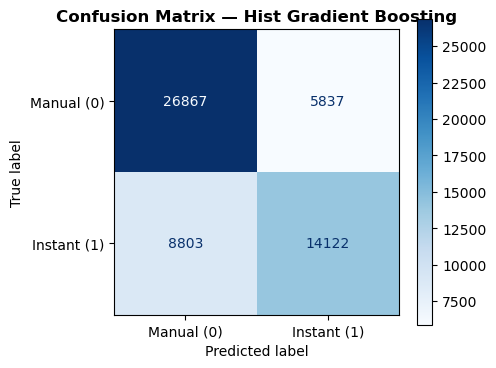

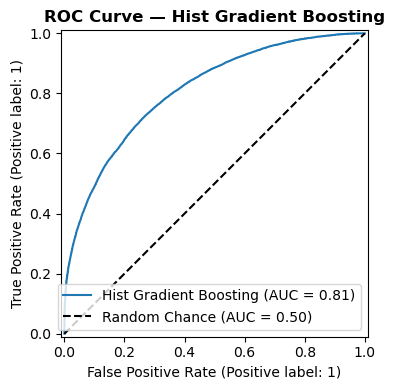

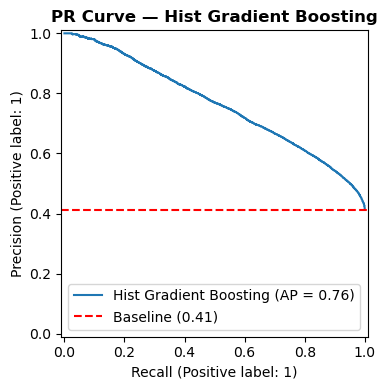

2026/08/26 04:00:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference tim

🏃 View run team14_s1401_hist_gradient_boosting at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/8bf17a6a27f842ce80a7e33a2703351d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2

HIST GRADIENT BOOSTING RESULTS (Run ID: 8bf17a6a27f842ce80a7e33a2703351d)
  TEST  test_accuracy            : 0.7368
  TEST  test_brier_score         : 0.1730
  TEST  test_f1                  : 0.6586
  TEST  test_log_loss            : 0.5170
  TEST  test_pr_auc              : 0.7647
  TEST  test_precision           : 0.7076
  TEST  test_recall              : 0.6160
  TEST  test_roc_auc             : 0.8093
  TRAIN train_accuracy           : 0.7427
  TRAIN train_brier_score        : 0.1709
  TRAIN train_f1                 : 0.6657
  TRAIN train_log_loss           : 0.5119
  TRAIN train_pr_auc             : 0.7716
  TRAIN train_precision          : 0.7166
  TRAIN train_recall             : 0.6216
  TRAIN train_roc_auc            : 0.8143


,Metric,Train,Test
0,Accuracy,0.7427,0.7368
1,ROC-AUC,0.8143,0.8093
2,PR-AUC,0.7716,0.7647
3,F1-Score,0.6657,0.6586
4,Precision,0.7166,0.7076
5,Recall,0.6216,0.6160
6,Log-Loss,0.5119,0.5170
7,Brier Score,0.1709,0.1730


In [10]:
# ==============================================================================
# RUN 3: HIST GRADIENT BOOSTING CLASSIFIER
# ==============================================================================

import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from IPython.display import display

# 1. Configuration & Hyperparameters
run_name = (
    f"{TEAM_ID}_{STUDENT_ID}_hist_gradient_boosting"
    if "TEAM_ID" in globals()
    else "03_Hist_Gradient_Boosting"
)

HGB_PARAMS = {
    "max_iter": 100,
    "learning_rate": 0.1,
    "max_depth": 10,
    "min_samples_leaf": 20,
    "l2_regularization": 1.0,
    "random_state": 42,
}

# 2. Execute MLflow Run
with mlflow.start_run(run_name=run_name) as run:
    # --- Set Tags ---
    tags = {
        "model_family": "Ensemble",
        "model_type": "HistGradientBoostingClassifier",
        "experiment_stage": "Baseline",
        "target": "instant_bookable",
    }
    if "COMMON_TAGS" in globals():
        tags.update(COMMON_TAGS)
    mlflow.set_tags(tags)

    # --- Log Hyperparameters & Dataset Metadata ---
    mlflow.log_params({
        **HGB_PARAMS,
        "n_features": X_train.shape[1],
        "train_size": X_train.shape[0],
    })

    # --- Train Model ---
    print(f"Training {run_name}...")
    model_hgb = HistGradientBoostingClassifier(**HGB_PARAMS)
    model_hgb.fit(X_train, y_train)

    # --- Compute & Log Metrics using Helper Function ---
    metrics_hgb = evaluate_model(model_hgb, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics_hgb)

    # --- Log Diagnostic Plots using Helper Functions ---
    log_confusion_matrix(model_hgb, X_test, y_test, title="Hist Gradient Boosting")
    log_roc_curve(model_hgb, X_test, y_test, title="Hist Gradient Boosting")
    log_pr_curve(model_hgb, X_test, y_test, title="Hist Gradient Boosting")

    # --- Log Model Artifact ---
    mlflow.sklearn.log_model(
        sk_model=model_hgb,
        artifact_path="model",
        input_example=X_train.head(5),
    )

    # --- Capture Run ID ---
    HGB_RUN_ID = run.info.run_id

# ==============================================================================
# 3. Print Results & Display Performance Table
# ==============================================================================
print("\n" + "=" * 50)
print(f"HIST GRADIENT BOOSTING RESULTS (Run ID: {HGB_RUN_ID})")
print("=" * 50)

for k, v in sorted(metrics_hgb.items()):
    split = "TRAIN" if k.startswith("train") else "TEST "
    print(f"  {split} {k:<25}: {v:.4f}" if isinstance(v, float) else f"  {split} {k:<25}: {v}")

df_results_hgb = pd.DataFrame([
    {"Metric": "Accuracy",     "Train": metrics_hgb.get("train_accuracy"),     "Test": metrics_hgb.get("test_accuracy")},
    {"Metric": "ROC-AUC",      "Train": metrics_hgb.get("train_roc_auc"),      "Test": metrics_hgb.get("test_roc_auc")},
    {"Metric": "PR-AUC",       "Train": metrics_hgb.get("train_pr_auc"),       "Test": metrics_hgb.get("test_pr_auc")},
    {"Metric": "F1-Score",     "Train": metrics_hgb.get("train_f1"),           "Test": metrics_hgb.get("test_f1")},
    {"Metric": "Precision",    "Train": metrics_hgb.get("train_precision"),    "Test": metrics_hgb.get("test_precision")},
    {"Metric": "Recall",       "Train": metrics_hgb.get("train_recall"),       "Test": metrics_hgb.get("test_recall")},
    {"Metric": "Log-Loss",     "Train": metrics_hgb.get("train_log_loss"),     "Test": metrics_hgb.get("test_log_loss")},
    {"Metric": "Brier Score",  "Train": metrics_hgb.get("train_brier_score"),  "Test": metrics_hgb.get("test_brier_score")},
])

display(df_results_hgb)

Calculating permutation importance (this may take a moment)...



Top 20 Features (Hist Gradient Boosting):


,Feature,Permutation Importance (Mean)
0,host_acceptance_rate,0.067285
1,host_tenure_days,0.032070
2,host_total_listings_count,0.019040
3,room_type_Hotel room,0.005763
4,host_acceptance_rate_isna,0.003897
5,longitude,0.003622
6,minimum_nights,0.003610
7,host_response_time_within an hour,0.003173
8,review_scores_rating,0.003060
9,host_response_rate_isna,0.002961


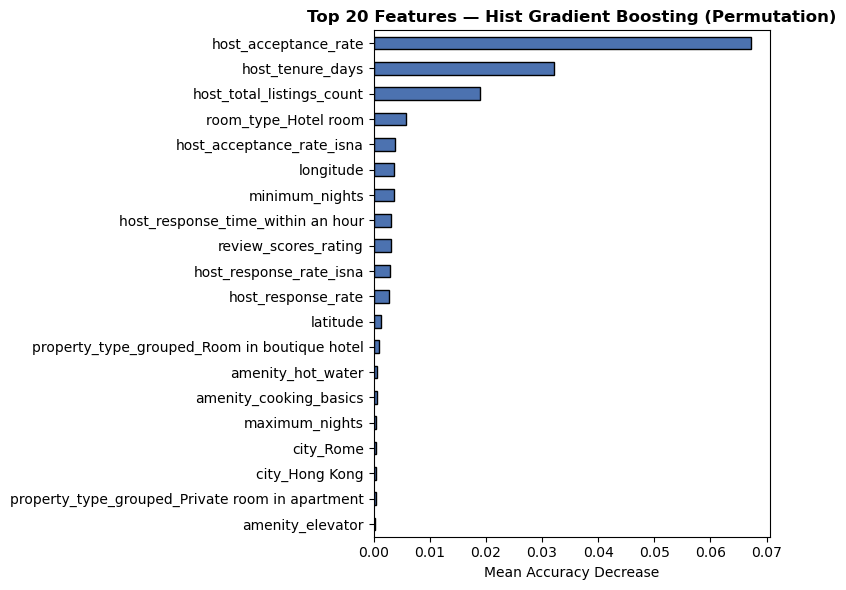

In [11]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 4. Hist Gradient Boosting Feature Importance (Permutation)
# ==============================================================================

print("Calculating permutation importance (this may take a moment)...")

# 1. Calculate permutation importance on the test set
# This measures how much the model's performance drops if a feature is shuffled
hgb_importance_results = permutation_importance(
    model_hgb, 
    X_test, 
    y_test, 
    n_repeats=10,      # Number of times to shuffle each feature
    random_state=42, 
    n_jobs=-1          # Use all available CPU cores
)

# 2. Map importances to feature names and get the Top 20
hgb_importances = pd.Series(hgb_importance_results.importances_mean, index=X_test.columns)
top_20_hgb = hgb_importances.sort_values(ascending=False).head(20)

# 3. Display as a clean DataFrame
df_top_20_hgb = top_20_hgb.reset_index()
df_top_20_hgb.columns = ['Feature', 'Permutation Importance (Mean)']
print("\nTop 20 Features (Hist Gradient Boosting):")
display(df_top_20_hgb)

# 4. Plot the results to match your other notebook visuals
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
top_20_hgb.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='black')
ax.set_title('Top 20 Features — Hist Gradient Boosting (Permutation)', fontweight='bold')
ax.set_xlabel('Mean Accuracy Decrease')
plt.tight_layout()
plt.show()

## Comparision between Base Model , (LR vs RF vs historgram graident boosting)

In [12]:
# ==============================================================================
# 8. THREE-WAY BASELINE COMPARISON (LR vs RF vs HGB)
# ==============================================================================

import pandas as pd
from IPython.display import display

# Retrieve metrics dictionaries safely from global scope
lr_bench = globals().get("metrics_lr", {})
rf_bench = globals().get("metrics_rf", {})
hgb_bench = globals().get("metrics_hgb", {})

metrics_keys = [
    ("Accuracy", "accuracy"),
    ("ROC-AUC", "roc_auc"),
    ("PR-AUC", "pr_auc"),
    ("F1-Score", "f1"),
    ("Precision", "precision"),
    ("Recall", "recall"),
    ("Log-Loss", "log_loss"),
    ("Brier Score", "brier_score"),
]

results_data = []

for label, key in metrics_keys:
    # LR values
    lr_test = lr_bench.get(f"test_{key}")
    
    # RF values
    rf_train = rf_bench.get(f"train_{key}")
    rf_test = rf_bench.get(f"test_{key}")
    
    # HGB values
    hgb_train = hgb_bench.get(f"train_{key}")
    hgb_test = hgb_bench.get(f"test_{key}")

    # Compute deltas relative to the LR baseline
    delta_rf_vs_lr = (
        round(rf_test - lr_test, 4)
        if (rf_test is not None and lr_test is not None)
        else "N/A"
    )
    delta_hgb_vs_lr = (
        round(hgb_test - lr_test, 4)
        if (hgb_test is not None and lr_test is not None)
        else "N/A"
    )
    delta_hgb_vs_rf = (
        round(hgb_test - rf_test, 4)
        if (hgb_test is not None and rf_test is not None)
        else "N/A"
    )

    results_data.append({
        "Metric": label,
        "LR (Test)": lr_test,
        "RF (Train)": rf_train,
        "RF (Test)": rf_test,
        "HGB (Train)": hgb_train,
        "HGB (Test)": hgb_test,
        "Δ RF vs LR": delta_rf_vs_lr,
        "Δ HGB vs LR": delta_hgb_vs_lr,
        "Δ HGB vs RF": delta_hgb_vs_rf,
    })

df_model_comparison = pd.DataFrame(results_data)

print("\n--- Baseline Model Comparison (LR vs RF vs HGB) ---", flush=True)
display(df_model_comparison)


--- Baseline Model Comparison (LR vs RF vs HGB) ---


,Metric,LR (Test),RF (Train),RF (Test),HGB (Train),HGB (Test),Δ RF vs LR,Δ HGB vs LR,Δ HGB vs RF
0,Accuracy,0.7049,0.7999,0.7493,0.7427,0.7368,0.0444,0.0319,-0.0125
1,ROC-AUC,0.7612,0.8805,0.8219,0.8143,0.8093,0.0607,0.0481,-0.0126
2,PR-AUC,0.6895,0.8565,0.7873,0.7716,0.7647,0.0978,0.0752,-0.0226
3,F1-Score,0.6069,0.7317,0.6626,0.6657,0.6586,0.0557,0.0517,-0.0040
4,Precision,0.6726,0.8178,0.7441,0.7166,0.7076,0.0715,0.0350,-0.0365
5,Recall,0.5529,0.6621,0.5971,0.6216,0.6160,0.0442,0.0631,0.0189
6,Log-Loss,0.5708,0.4605,0.5108,0.5119,0.5170,-0.0600,-0.0538,0.0062
7,Brier Score,0.1936,0.1475,0.1694,0.1709,0.1730,-0.0242,-0.0206,0.0036


## Run 3 — Hyperparameter RF_Tuning with Nested Runs

RANDOM FOREST TUNING (NESTED RUNS) - START


>>> MLflow ready.



>>> Total Hyperparameter Combinations: 72


>>> SEARCH SPACE GRID:


    n_estimators: [50, 100, 150]


...

  [72/72] n_est=150, depth=20, split=10, leaf=4 --> Test ROC-AUC: 0.8262


🏃 View run Trial_72 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/1235f92b3a524b10bd7b546746008331
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2



>>> Nested trials completed.


>>> Best Selection Score (ROC-AUC): 0.8383



>>> Logging best model metadata to Parent Run...


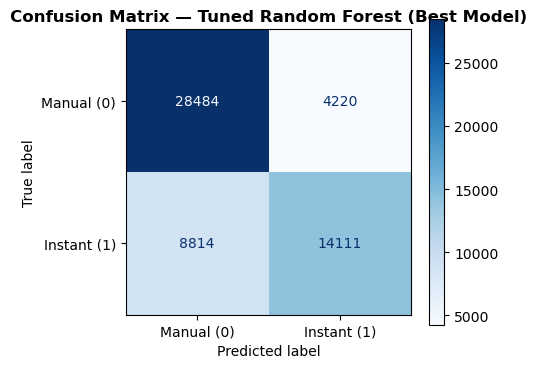

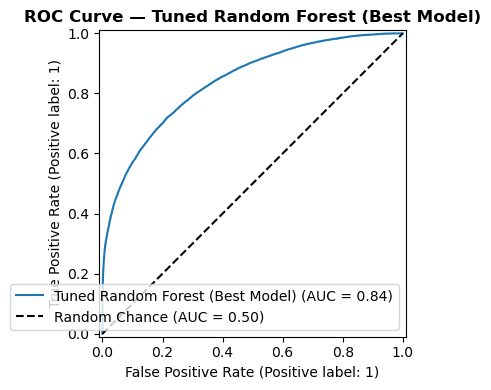

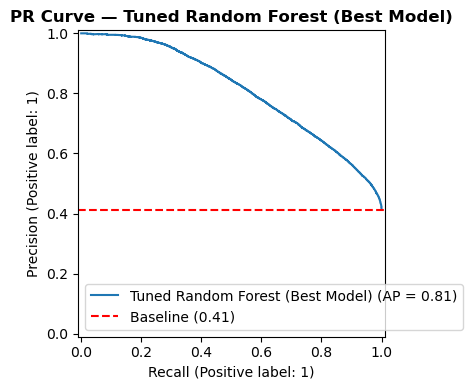

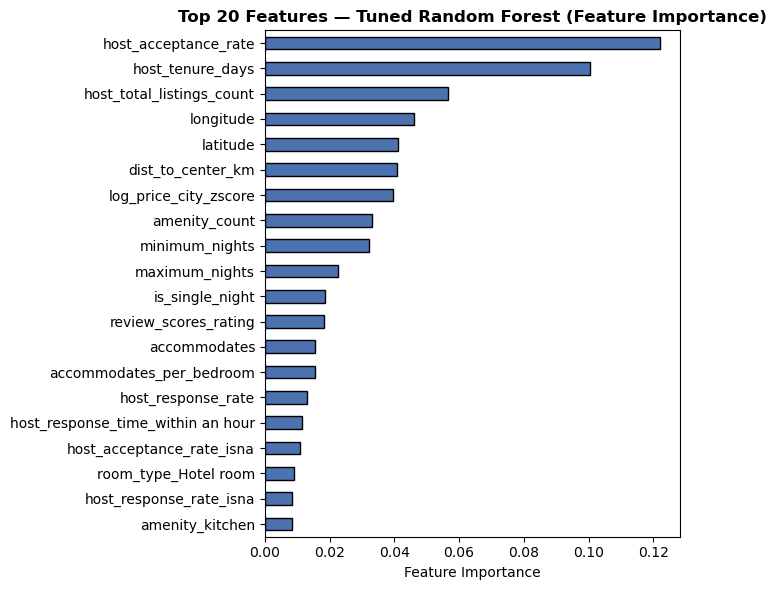

2026/08/26 04:54:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference tim

2026/08/26 05:22:24 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmppj7s62zw/model/model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'skops==0.14.0']. Set logging level to DEBUG to see the full traceback. 


>>> Best model artifacts successfully logged.


🏃 View run team14_s1401_random_forest_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/269122992643415f9a14e4ff035f2595
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2



>>> Parent MLflow run closed.


In [13]:
# ==============================================================================
# CELL 1: RANDOM FOREST HYPERPARAMETER TUNING (NESTED RUNS)
# ==============================================================================

from IPython.display import display
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid

print("=" * 70, flush=True)
print("RANDOM FOREST TUNING (NESTED RUNS) - START", flush=True)
print("=" * 70, flush=True)

# 1. Close previous MLflow run if open
if mlflow.active_run() is not None:
    print(">>> Closing previous MLflow run...", flush=True)
    mlflow.end_run()
print(">>> MLflow ready.", flush=True)

# 2. Define run name and hyperparameter search space
parent_run_name = (
    f"{TEAM_ID}_{STUDENT_ID}_random_forest_tuning"
    if "TEAM_ID" in globals()
    else "03_Random_Forest_Tuning"
)

PARAM_GRID = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", "log2"],
    "random_state": [42],
    "n_jobs": [2],
}

param_combinations = list(ParameterGrid(PARAM_GRID))
total_trials = len(param_combinations)

print(f"\n>>> Total Hyperparameter Combinations: {total_trials}", flush=True)
print(">>> SEARCH SPACE GRID:", flush=True)
for k, v in PARAM_GRID.items():
    print(f"    {k}: {v}", flush=True)

# 3. Execute Parent & Nested Child Runs
best_score = -float("inf")
best_params = None
best_model_rf = None
best_metrics = None

print("\n>>> Starting Parent MLflow Run...", flush=True)

with mlflow.start_run(run_name=parent_run_name) as parent_run:
    RF_TUNING_PARENT_ID = parent_run.info.run_id
    print(f">>> MLflow Parent Run ID: {RF_TUNING_PARENT_ID}", flush=True)

    # Parent Tags
    parent_tags = {
        "model_family": "Ensemble",
        "model_type": "RandomForestClassifier",
        "experiment_stage": "Hyperparameter_Tuning",
        "target": "instant_bookable",
        "tuning_strategy": "GridSearch_Nested",
    }
    if "COMMON_TAGS" in globals():
        parent_tags.update(COMMON_TAGS)
    mlflow.set_tags(parent_tags)
    print(">>> Parent tags logged.", flush=True)

    # Iterate Child Trials
    print("\n>>> Starting Nested Trials...", flush=True)

    for idx, params in enumerate(param_combinations, 1):
        child_run_name = f"Trial_{idx:02d}"

        with mlflow.start_run(run_name=child_run_name, nested=True):
            # Fit candidate model
            trial_model = RandomForestClassifier(**params)
            trial_model.fit(X_train, y_train)

            # Evaluate candidate
            trial_metrics = evaluate_model(
                trial_model, X_train, y_train, X_test, y_test
            )

            # Log Child Parameters & Metrics
            mlflow.log_params(params)
            mlflow.log_metrics(trial_metrics)

            # Selection metric (Test ROC-AUC primary)
            primary_metric = trial_metrics.get(
                "test_roc_auc", trial_metrics.get("test_accuracy", 0)
            )

            print(
                f"  [{idx:02d}/{total_trials:02d}] "
                f"n_est={params['n_estimators']}, depth={params['max_depth']}, "
                f"split={params['min_samples_split']}, leaf={params['min_samples_leaf']} "
                f"--> Test ROC-AUC: {primary_metric:.4f}",
                flush=True,
            )

            # Track Best Model
            if primary_metric > best_score:
                best_score = primary_metric
                best_params = params
                best_model_rf = trial_model
                best_metrics = trial_metrics

    print("\n>>> Nested trials completed.", flush=True)
    print(f">>> Best Selection Score (ROC-AUC): {best_score:.4f}", flush=True)

    # 4. Log Best Run Summary & Artifacts in Parent Run
    print("\n>>> Logging best model metadata to Parent Run...", flush=True)

    mlflow.log_params(
        {
            **{f"best_{k}": v for k, v in best_params.items()},
            "total_combinations_tested": total_trials,
            "n_features": X_train.shape[1],
            "train_size": X_train.shape[0],
        }
    )
    mlflow.log_metrics(best_metrics)

    # Artifact logging
    log_confusion_matrix(
        best_model_rf, X_test, y_test, title="Tuned Random Forest (Best Model)"
    )
    log_roc_curve(
        best_model_rf, X_test, y_test, title="Tuned Random Forest (Best Model)"
    )
    log_pr_curve(
        best_model_rf, X_test, y_test, title="Tuned Random Forest (Best Model)"
    )
    log_feature_importance(
        best_model_rf,
        feature_names=X_train.columns,
        title="Tuned Random Forest (Feature Importance)",
        top_n=20,
    )

    # Log model artifact
    mlflow.sklearn.log_model(
        sk_model=best_model_rf,
        artifact_path="best_model",
        input_example=X_train.head(5),
    )
    print(">>> Best model artifacts successfully logged.", flush=True)

print("\n>>> Parent MLflow run closed.", flush=True)

In [14]:
# ==============================================================================
# CELL 2: DISPLAY BEST RANDOM FOREST HYPERPARAMETERS & METRICS
# ==============================================================================

import pandas as pd
from IPython.display import display

print("=" * 70)
print("BEST RANDOM FOREST HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

# 1. Print MLflow Run & Score Overview
print(f"\n MLflow Parent Run ID : {RF_TUNING_PARENT_ID}")
print(f" Best Selection Score  : {best_score:.4f} (Test ROC-AUC)")
print("-" * 70)

# 2. Display Best Hyperparameters
print("\n>>> Optimal Hyperparameters:")
for param, val in best_params.items():
    print(f"    • {param:<20}: {val}")

# 3. Tabular Representation of Parameters & Metrics
df_best_params = pd.DataFrame(
    list(best_params.items()), columns=["Hyperparameter", "Optimal Value"]
)

print("\n--- Hyperparameter Summary Table ---")
display(df_best_params)

if best_metrics:
    df_best_metrics = pd.DataFrame(
        [
            {"Metric": k, "Score": f"{v:.4f}" if isinstance(v, float) else v}
            for k, v in best_metrics.items()
        ]
    )
    print("\n--- Performance Metrics Table ---")
    display(df_best_metrics)

print("=" * 70)

BEST RANDOM FOREST HYPERPARAMETER TUNING RESULTS

 MLflow Parent Run ID : 269122992643415f9a14e4ff035f2595
 Best Selection Score  : 0.8383 (Test ROC-AUC)
----------------------------------------------------------------------

>>> Optimal Hyperparameters:
    • max_depth           : 20
    • max_features        : sqrt
    • min_samples_leaf    : 2
    • min_samples_split   : 5
    • n_estimators        : 150
    • n_jobs              : 2
    • random_state        : 42

--- Hyperparameter Summary Table ---


,Hyperparameter,Optimal Value
0,max_depth,20
1,max_features,sqrt
2,min_samples_leaf,2
3,min_samples_split,5
4,n_estimators,150
5,n_jobs,2
6,random_state,42



--- Performance Metrics Table ---


,Metric,Score
0,train_accuracy,0.9031
1,train_precision,0.9477
2,train_recall,0.8095
3,train_f1,0.8732
4,train_roc_auc,0.9686
5,train_pr_auc,0.9625
6,train_log_loss,0.3410
7,train_brier_score,0.0977
8,test_accuracy,0.7657
9,test_precision,0.7698



MODEL PROGRESSION COMPARISON TABLE


,Metric,LR Baseline (Test),RF Baseline (Test),HGB (Test),RF Tuned (Test),Δ (HGB vs LR),Δ (Tuned vs HGB),Δ (Tuned vs LR)
0,Accuracy,0.7049,0.7493,0.7368,0.7657,0.0319,0.0289,0.0608
1,ROC-AUC,0.7612,0.8219,0.8093,0.8383,0.0481,0.0290,0.0771
2,PR-AUC,0.6895,0.7873,0.7647,0.8111,0.0752,0.0464,0.1216
3,F1-Score,0.6069,0.6626,0.6586,0.6841,0.0517,0.0255,0.0772
4,Precision,0.6726,0.7441,0.7076,0.7698,0.0350,0.0622,0.0972
5,Recall,0.5529,0.5971,0.6160,0.6155,0.0631,-0.0005,0.0626
6,Log-Loss,0.5708,0.5108,0.5170,0.4873,-0.0538,-0.0297,-0.0835
7,Brier Score,0.1936,0.1694,0.1730,0.1605,-0.0206,-0.0125,-0.0331


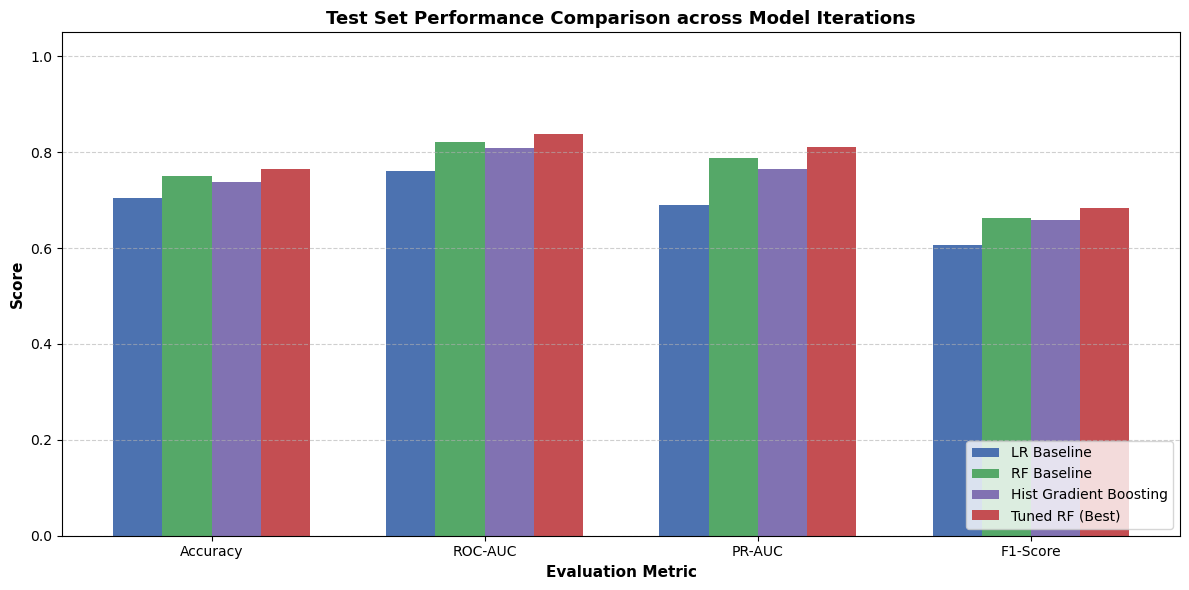

In [15]:
# ==============================================================================
# CELL 2: VISUAL COMPARISON OF EXPERIMENT RUNS (LR vs RF BASE vs HGB vs TUNED RF)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Fetch metrics dictionaries from global scope
lr_bench = globals().get("metrics_lr", {})
rf_base_bench = globals().get("metrics_rf", {})
hgb_bench = globals().get("metrics_hgb", {})

metrics_keys = [
    ("Accuracy", "accuracy"),
    ("ROC-AUC", "roc_auc"),
    ("PR-AUC", "pr_auc"),
    ("F1-Score", "f1"),
    ("Precision", "precision"),
    ("Recall", "recall"),
    ("Log-Loss", "log_loss"),
    ("Brier Score", "brier_score"),
]

# 1. Build Tabular Comparison
comparison_rows = []
for label, key in metrics_keys:
    lr_val = lr_bench.get(f"test_{key}")
    rf_base_val = rf_base_bench.get(f"test_{key}")
    hgb_val = hgb_bench.get(f"test_{key}")
    rf_tuned_val = best_metrics.get(f"test_{key}") if "best_metrics" in globals() and best_metrics else None

    # Delta comparisons
    delta_hgb_vs_lr = (
        round(hgb_val - lr_val, 4)
        if (hgb_val is not None and lr_val is not None)
        else "N/A"
    )
    delta_tuned_vs_hgb = (
        round(rf_tuned_val - hgb_val, 4)
        if (rf_tuned_val is not None and hgb_val is not None)
        else "N/A"
    )
    delta_tuned_vs_lr = (
        round(rf_tuned_val - lr_val, 4)
        if (rf_tuned_val is not None and lr_val is not None)
        else "N/A"
    )

    comparison_rows.append(
        {
            "Metric": label,
            "LR Baseline (Test)": round(lr_val, 4) if lr_val is not None else "N/A",
            "RF Baseline (Test)": round(rf_base_val, 4) if rf_base_val is not None else "N/A",
            "HGB (Test)": round(hgb_val, 4) if hgb_val is not None else "N/A",
            "RF Tuned (Test)": round(rf_tuned_val, 4) if rf_tuned_val is not None else "N/A",
            "Δ (HGB vs LR)": delta_hgb_vs_lr,
            "Δ (Tuned vs HGB)": delta_tuned_vs_hgb,
            "Δ (Tuned vs LR)": delta_tuned_vs_lr,
        }
    )

df_model_comparison = pd.DataFrame(comparison_rows)

print("\n" + "=" * 80)
print("MODEL PROGRESSION COMPARISON TABLE")
print("=" * 80)
display(df_model_comparison)

# 2. Visual Bar Chart Comparison for Key Classification Metrics
plot_metrics = ["Accuracy", "ROC-AUC", "PR-AUC", "F1-Score"]
df_plot = df_model_comparison[
    df_model_comparison["Metric"].isin(plot_metrics)
].copy()

# Replace missing strings with 0 for plotting
for col in [
    "LR Baseline (Test)",
    "RF Baseline (Test)",
    "HGB (Test)",
    "RF Tuned (Test)",
]:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce").fillna(0)

x = np.arange(len(plot_metrics))
bar_width = 0.18  # Scaled for 4 models per metric

plt.figure(figsize=(12, 6))

plt.bar(
    x - 1.5 * bar_width,
    df_plot["LR Baseline (Test)"],
    width=bar_width,
    label="LR Baseline",
    color="#4C72B0",
)
plt.bar(
    x - 0.5 * bar_width,
    df_plot["RF Baseline (Test)"],
    width=bar_width,
    label="RF Baseline",
    color="#55A868",
)
plt.bar(
    x + 0.5 * bar_width,
    df_plot["HGB (Test)"],
    width=bar_width,
    label="Hist Gradient Boosting",
    color="#8172B2",
)
plt.bar(
    x + 1.5 * bar_width,
    df_plot["RF Tuned (Test)"],
    width=bar_width,
    label="Tuned RF (Best)",
    color="#C44E52",
)

plt.xlabel("Evaluation Metric", fontsize=11, fontweight="bold")
plt.ylabel("Score", fontsize=11, fontweight="bold")
plt.title(
    "Test Set Performance Comparison across Model Iterations",
    fontsize=13,
    fontweight="bold",
)
plt.xticks(x, plot_metrics, fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(frameon=True, facecolor="white", loc="lower right")
plt.tight_layout()
plt.show()

In [16]:
# ==============================================================================
# CELL 3: QUALITY GATE AND BEST MODEL SELECTION
# ==============================================================================

QUALITY_GATE = 0.75

# Extract Best Run Info from Tuned Model execution
BEST_AUC = best_score
BEST_RUN_ID = RF_TUNING_PARENT_ID
BEST_RUN_NAME = parent_run_name

print("=" * 60)
print("QUALITY GATE")
print("=" * 60)

if BEST_AUC < QUALITY_GATE:
    print(f"❌ Quality gate FAILED")
    print(f"Best AUC : {BEST_AUC:.4f}")
    print(f"Required : {QUALITY_GATE:.2f}")
    print("\nReview feature engineering or hyperparameters before proceeding.")
    BEST_MODEL_URI = None
else:
    print(f"✅ Quality gate PASSED")
    print(f"Best AUC : {BEST_AUC:.4f}")

    # Export information for downstream stages / Notebook 03
    BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/best_model"
    
    print("\nCopy these values into Notebook 03 if required:\n")
    print("\nBest MLflow Run")
    print("-" * 60)
    print(f"Run Name   : {BEST_RUN_NAME}")
    print(f"Run ID     : {BEST_RUN_ID}")
    print(f"Model URI  : {BEST_MODEL_URI}")
    print(f"Best AUC   : {BEST_AUC:.4f}")

print("=" * 60)

QUALITY GATE
✅ Quality gate PASSED
Best AUC : 0.8383

Copy these values into Notebook 03 if required:


Best MLflow Run
------------------------------------------------------------
Run Name   : team14_s1401_random_forest_tuning
Run ID     : 269122992643415f9a14e4ff035f2595
Model URI  : runs:/269122992643415f9a14e4ff035f2595/best_model
Best AUC   : 0.8383


In [17]:
# ==========================================================
# Notebook 03 Inputs
# ==========================================================



print(f'BEST_RUN_ID    = "{BEST_RUN_ID}"')

if BEST_MODEL_URI is not None:
    print(f'BEST_MODEL_URI = "{BEST_MODEL_URI}"')

print(f"BEST_AUC       = {BEST_AUC:.4f}")
print(f'BEST_RUN_NAME  = "{BEST_RUN_NAME}"')

BEST_RUN_ID    = "269122992643415f9a14e4ff035f2595"
BEST_MODEL_URI = "runs:/269122992643415f9a14e4ff035f2595/best_model"
BEST_AUC       = 0.8383
BEST_RUN_NAME  = "team14_s1401_random_forest_tuning"


In [18]:
# Write to JSON file so Notebook 03 can read it.
import json

best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_auc": float(BEST_AUC),
    "best_model_uri": BEST_MODEL_URI,
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
}

with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=4)

print("Saved best model information to best_model.json")
print(json.dumps(best_model_info, indent=2))

Saved best model information to best_model.json
{
  "team_id": "team14",
  "student_id": "s1401",
  "project_name": "airbnb-instant-booking",
  "best_run_id": "269122992643415f9a14e4ff035f2595",
  "best_run_name": "team14_s1401_random_forest_tuning",
  "best_auc": 0.8383,
  "best_model_uri": "runs:/269122992643415f9a14e4ff035f2595/best_model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS",
  "mlflow_experiment": "ITI113/team14/InstantBooking-Classification",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team14"
}


In [19]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
artifacts = client.list_artifacts(BEST_RUN_ID)

for a in artifacts:
    print(a.path, a.is_dir)

plots True


In [20]:
# Load best model directly from the best MLflow run and test inference
loaded = mlflow.sklearn.load_model(BEST_MODEL_URI)

sample = X_test.head(5)
preds = loaded.predict(sample)
probas = loaded.predict_proba(sample)[:, 1]

results = pd.DataFrame({
    "actual": y_test.head(5).values,
    "predicted": preds,
    "probability (Class 1)": probas.round(3),
    "correct": preds == y_test.head(5).values
})

print("Sample predictions from best MLflow run model:")
print(results.to_string(index=False))

Sample predictions from best MLflow run model:
 actual  predicted  probability (Class 1)  correct
      0          0                  0.387     True
      0          0                  0.371     True
      1          1                  0.671     True
      0          0                  0.146     True
      0          0                  0.195     True


In [21]:
print("=" * 55)
print("NOTEBOOK 02 COMPLETE")
print("=" * 55)
print(f"Experiment : {MLFLOW_EXPERIMENT}")
print(f"MLflow App : {MLFLOW_APP_ARN}")
print(f"Best model : {BEST_RUN_NAME} | AUC={BEST_AUC:.4f}")
print(f"Best run ID: {BEST_RUN_ID}")
print(f"Model URI  : {BEST_MODEL_URI}")
print()
print("Next: Notebook 03 — run the SageMaker Pipeline using the same team S3 folder.")
print("For AWS-native tracking, use the same SageMaker MLflow App ARN in later notebooks.")

NOTEBOOK 02 COMPLETE
Experiment : ITI113/team14/InstantBooking-Classification
MLflow App : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Best model : team14_s1401_random_forest_tuning | AUC=0.8383
Best run ID: 269122992643415f9a14e4ff035f2595
Model URI  : runs:/269122992643415f9a14e4ff035f2595/best_model

Next: Notebook 03 — run the SageMaker Pipeline using the same team S3 folder.
For AWS-native tracking, use the same SageMaker MLflow App ARN in later notebooks.


## Checklist before Notebook 03

[] Notebook 01A created or reused the SageMaker MLflow App with TeamId tag

[] mlflow_app_config_<team_id>.json or mlflow_app_config_<team_id>_<student_id>.json is available, or DEFAULT_MLFLOW_APP_ARN was verified

[] SageMaker MLflow App connection working

[] MLflow App tag TeamId matches notebook TEAM_ID

[] Logistic Regression baseline logged to SageMaker MLflow App

[] Random Forest baseline logged to SageMaker MLflow App

[] Hyperparameter tuning nested runs visible in the SageMaker MLflow UI

[] Quality gate passed (Best Test AUC ≥ 0.75)

[] Best MLflow run identified

[] BEST_RUN_ID recorded

[] BEST_MODEL_URI generated successfully

[] Able to load the best model from the MLflow Run URI and make predictions

[] best_model.json generated with MLflow App tracking details

→ Continue to Notebook 03 to orchestrate training, model registration and deployment using SageMaker Pipelines.

In [22]:
print("Number of features:", X_train.shape[1])
print("\nFeature names:")

for i, feature in enumerate(X_train.columns, start=1):
    print(f"{i:3}. {feature}")

Number of features: 100

Feature names:
  1. host_response_rate
  2. host_acceptance_rate
  3. host_is_superhost
  4. host_total_listings_count
  5. host_has_profile_pic
  6. host_identity_verified
  7. latitude
  8. longitude
  9. accommodates
 10. bedrooms
 11. minimum_nights
 12. maximum_nights
 13. review_scores_rating
 14. review_scores_accuracy
 15. review_scores_cleanliness
 16. review_scores_checkin
 17. review_scores_communication
 18. review_scores_location
 19. review_scores_value
 20. host_response_rate_isna
 21. host_acceptance_rate_isna
 22. host_response_time_isna
 23. review_scores_rating_isna
 24. review_scores_accuracy_isna
 25. review_scores_cleanliness_isna
 26. review_scores_checkin_isna
 27. review_scores_communication_isna
 28. review_scores_location_isna
 29. review_scores_value_isna
 30. bedrooms_isna
 31. amenity_count
 32. has_self_checkin
 33. has_keypad
 34. has_smart_lock
 35. has_lockbox
 36. has_building_staff
 37. has_keyless_entry_composite
 38. host_t

In [23]:
# ============================================================
# SAVE PROCESSED TRAIN/TEST DATA LOCALLY
# ============================================================

import os

local_dir = "./airbnb_processed"
os.makedirs(local_dir, exist_ok=True)

# Save processed datasets
X_train.to_csv(
    f"{local_dir}/train_features.csv",
    index=False
)

y_train.to_csv(
    f"{local_dir}/train_labels.csv",
    index=False,
    header=True
)

X_test.to_csv(
    f"{local_dir}/test_features.csv",
    index=False
)

y_test.to_csv(
    f"{local_dir}/test_labels.csv",
    index=False,
    header=True
)

print("Files saved to:", os.path.abspath(local_dir))

for file in os.listdir(local_dir):
    path = os.path.join(local_dir, file)
    print(f"  {file}: {os.path.getsize(path) / 1024 / 1024:.2f} MB")

Files saved to: /home/sagemaker-user/JG-Assignment/airbnb_processed
  train_features.csv: 115.38 MB
  train_labels.csv: 0.42 MB
  test_features.csv: 28.85 MB
  test_labels.csv: 0.11 MB
  .ipynb_checkpoints: 0.00 MB
